In [1]:
import numpy as np
from matplotlib import pyplot as plot, cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
domain = 2
nx = ny = 101
nt = 80
nu = 0.05
dx = domain / (nx - 1)
dy = domain / (ny - 1)

sigma = 0.25        # recall sigma = nu*dt/dx*dy
dt = sigma * dx * dy / nu

x = np.linspace(0, domain, nx)
y = np.linspace(0, domain, ny)

u = np.ones((nx, ny))

# initial conditions

u[int(0.5/dx):int((1/dx)+1), int(0.5/dy):int((1/dy)+1)] = 2

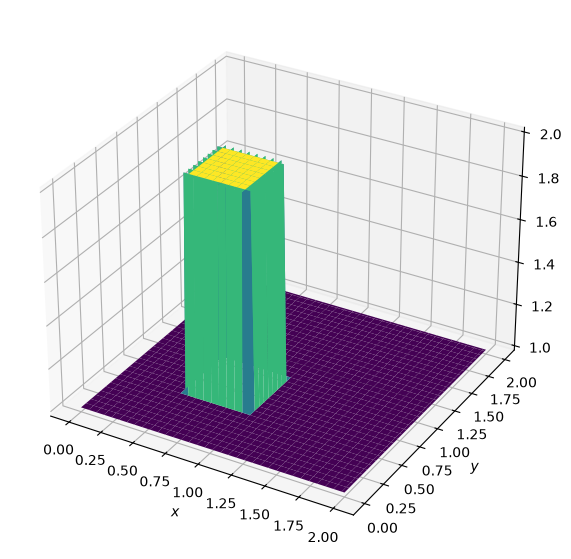

In [3]:
fig = plot.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.

X, Y = np.meshgrid(x, y)

surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$');

In [4]:
# discretization

def diffuse(nt):
    for n in range(nt):
        un = u.copy()
        u[1:-1,1:-1] =( un[1:-1,1:-1]
                    + nu * (dt/(dx)**2) * (un[:-2,1:-1] - 2*un[1:-1,1:-1] + un[2:,1:-1])
                    + nu * (dt/(dy**2)) * (un[1:-1,:-2] - 2*un[1:-1,1:-1] + un[1:-1,2:]) )

        # boundary conditions, u = 1 at x = 0, 2 and y = 0, 2
        u[0,:] = 1
        u[-1,:] = 1
        u[:,0] = 1
        u[:,-1] = 1

print('t = ', nt * dt)
diffuse(nt)

t =  0.16


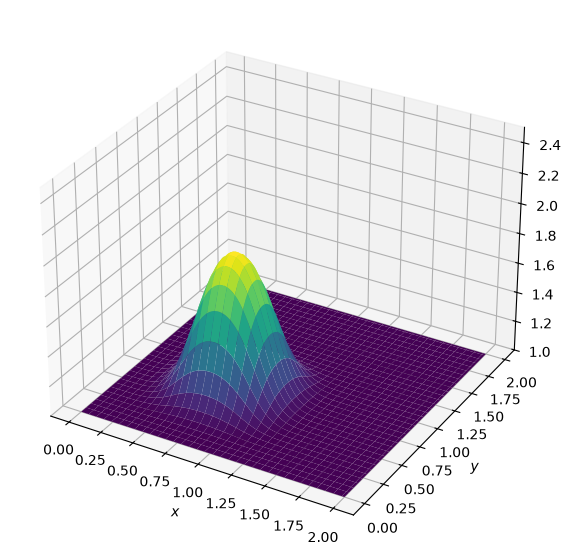

In [5]:
fig = plot.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.
surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)
ax.set_zlim(1, 2.5)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$');